### CS/ECE/ISyE 524 &mdash; Introduction to Optimization &mdash; Spring 2026 ###

# March Madness Bracket Optimization #

#### Ryan Logan (rrlogan@wisc.edu) & Tyler White (tkwhite3@wisc.edu)

### Table of Contents

1. [Introduction](#1.-Introduction)
1. [Mathematical Model](#2.-Mathematical-model)
1. [Implementation and Solution](#3.-Implementation)
1. [Discussion of Results](#4.-Results-discussion)
1. [Optional Subsection](#4.A.-Feel-free-to-add-subsections)
1. [Conclusion](#5.-Conclusion)

## 1. Introduction ##

March Madness is the annual tournament to determine the best team in college basketball. The tournament field consists of [37 at-large teams and 31 automatic qualifiers](https://www.espn.com/mens-college-basketball/story/_/id/48214906/march-madness-ncaa-men-women-tournament-seeding-brackets) who earned their spot by winning their conference tournament, with seeds being determined by a selection committee. After the bracket for the tournament is created, millions of people compete to guess the most correct winners and earn cash prizes or bragging rights. Despite the popularity of the bracket challenge, no perfect bracket has ever been created in the tournaments, with the odds of guessing every matchup correctly being [1 in 9.2 quintillion](https://www.ncaa.com/news/basketball-men/bracketiq/2026-02-18/perfect-ncaa-bracket-absurd-odds-march-madness-dream).
In order to aid in the hunt for the perfect bracket, our model will use metrics such as seed, quad 1 wins, and offensive/defensive efficiency to predict the outcome of every matchup. This means that each year the predicted outcomes will not be only tied to choosing the higher seed, yielding a potentially higher success rate in choosing matchups.
We will compare this model to the results of previous tournaments to determine whether the model is better than humans at predicting the flow of the tournament. Data can be pulled from NCAA websites and KenPom (for team statistics). We will create a model predicting the outcomes for this years bracket and compare it to the actual results from the tournament. The goal is to create a model that can correctly guess every matchup in the tournament!


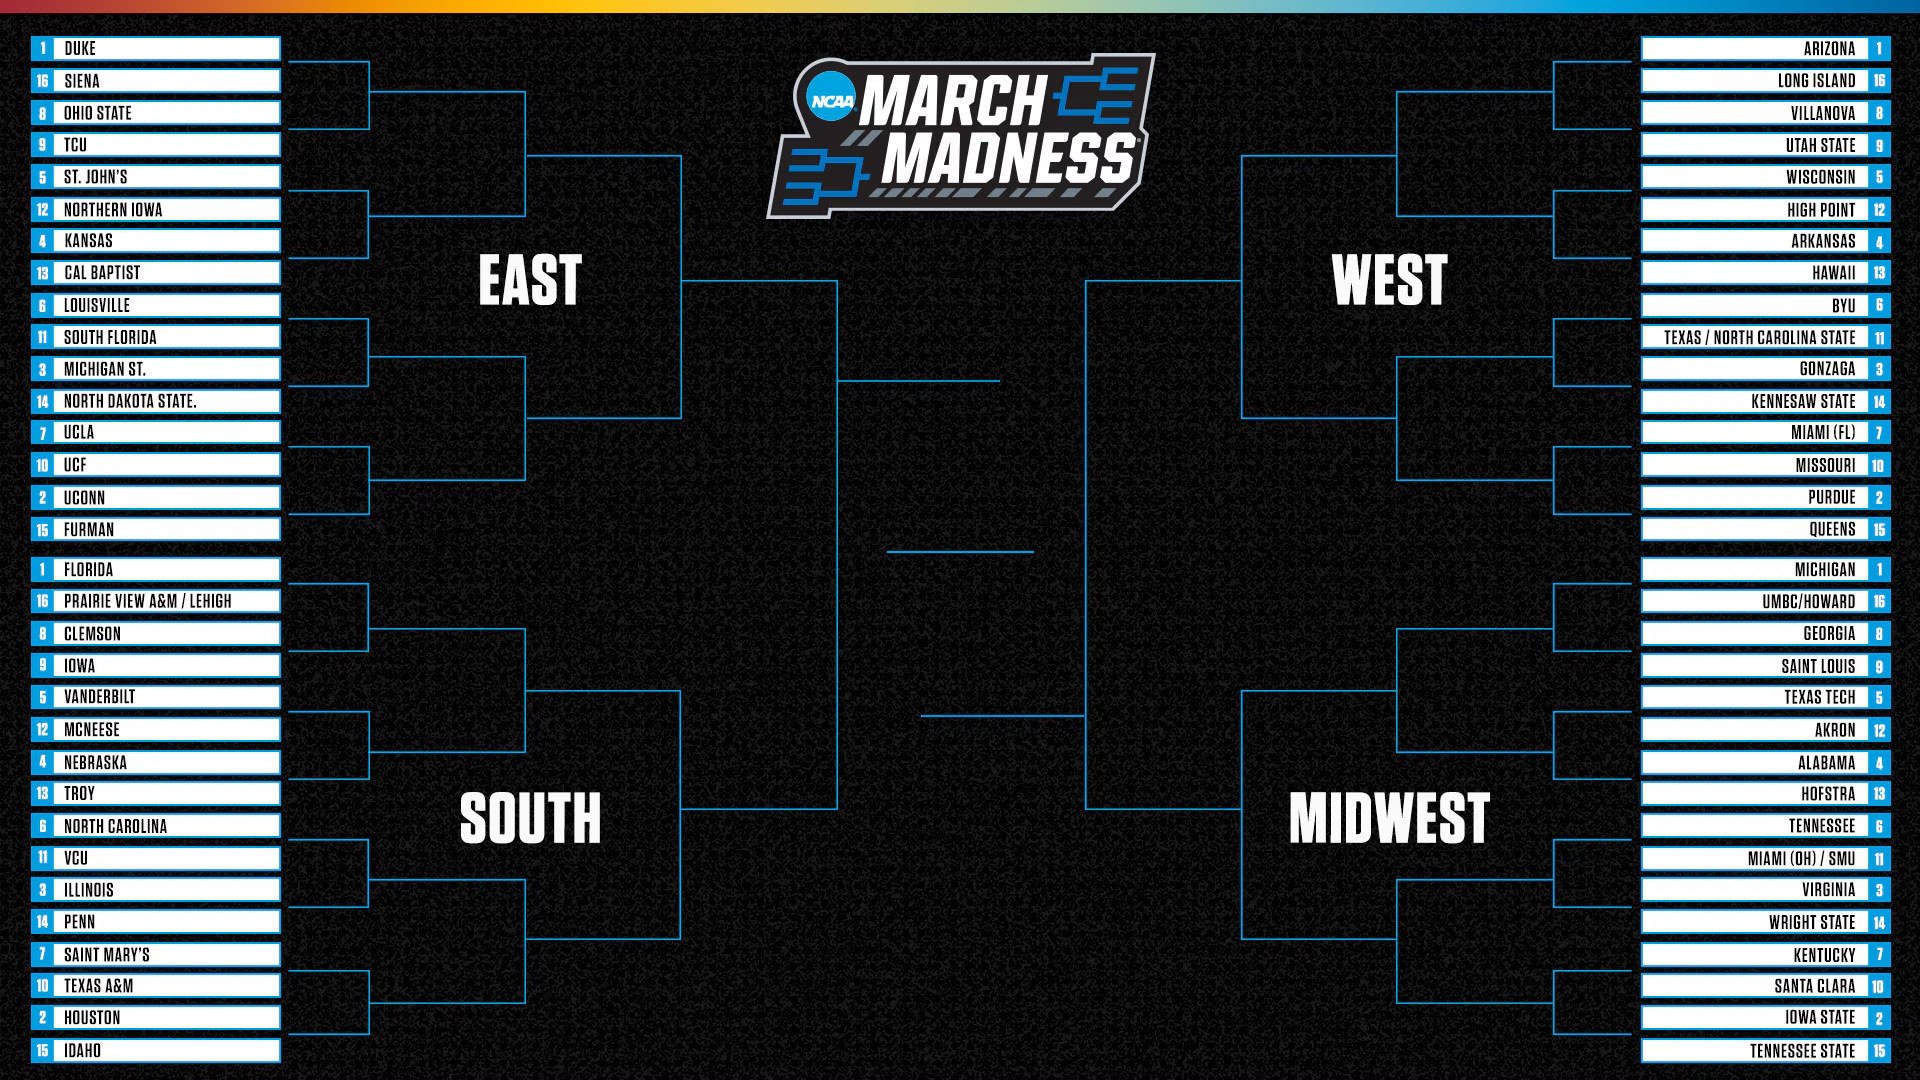

## 2. Mathematical model ##

Creating a model predicting outcomes for each game of a 68-team tournament can be a daunting task. To help simplify the problem we will start by creating a model with only 4 teams. We will take the 4 teams that made it to the final four and predict a winner from those teams. Once we get that model working we will expand our model to predict outcomes for every round of the tournament.

### 4-team math model ###
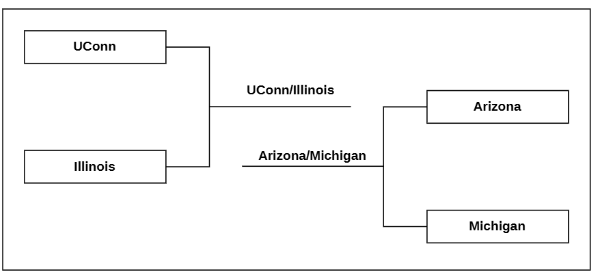

This problem is represented as a network flow problem where the game nodes act as "sinks" with a demand of 1. We will try to maximize the flow. Initially, teams will be assigned a value metric. When two teams meet head-to-head, the team with the greater value metric will win and move on in the tournament (Down the road, the value metric may be recalculated every round to more accurately reflect historical win-loss data).

 * $I = \set{Uconn, Illinois, Arizona, Michigan}$ 
 * $G = \set{UI, AM, CHAMP} = $ the set of the games to be played 
 * $N = $ the set of all nodes including the teams and games played 
 * $A = $ the set of arcs representing the bracket path 
 * $m_i = $ a metric showing the strength of team $i$
 * $d_k = $ the demand at each node where $d_k = 1$ for all $k \in G$
 * $x_{ij} = $ the flow on arc $(i, j)$, in this case represents the number of wins a team carries through
 * $p_{ij} = $ the points earned in game $(i,j)$


$$
\begin{align*}
\max \ & \sum_{i \in I} \sum_{(i,j) \in A} x_{ij}*m_i*p_{ij}\\
\text{s.t.} \ & \sum_{(i,k) \in A} x_{i,k} - \sum_{(k,j) \in A}x_{k,j} = 1\\
& x_{ir} \geq x_{i(r+1)}
\end{align*}
$$


## 3. Implementation \& Solutions ##

To begin, we will make a simplified model of the 64-team bracket. Let's first consider the case of the Final Four, where there are only four teams remaining and hence three games. For the 2026 tournament, the Final Four was comprised of UConn, Michigan, Arizona, and Illinois.

The criteria for who wins in a head to head will, for this example, be a teams free-throw percentage. This is not a good predictor of success in an actual bracket, but is a metric that is simple enough to use for this example. Of these teams, Illinois shot 78.04%, Michigan shot 74.75%, UConn shot 72.40%, and Arizona shot 73.42%. This data is pulled from the NCAA website.

In [30]:

using JuMP, HiGHS

teams = ["Illinois", "Michigan", "UConn", "Arizona"] # team names
percentages = [78.04, 74.75, 72.40, 73.42]# associated ft percentage
points = [160, 160, 320]


ff = Model(HiGHS.Optimizer) # final four bracket model

# let the demand of each game decision node be 1. Supply of the teams is infinite, for this case only need at most 2.
# the amount of flow out of each team's node will determine how far they go in the bracket
team_nodes = [:UConn, :Illinois, :Arizona, :Michigan]
interior_nodes = [:UI, :AM, :CHAMP]
nodes = vcat(team_nodes, interior_nodes)
interior_demands = Dict(t => 1 for t in interior_nodes)

# make the arcs between nodes
arcs = [(:UConn, :UI), (:Illinois, :UI), (:UI, :CHAMP), (:Arizona, :AM), (:Michigan, :AM), (:AM, :CHAMP)]

# map team names to ft percentage
ftp = Dict(
    :UConn => 72.40,
    :Illinois => 78.04,
    :Arizona => 73.42,
    :Michigan => 74.75
)


# decide the flow of each arc
@variable(ff, flow[arcs] >= 0)

# must meet the demand exactly for every node, aka inflow - outflow = demand
@constraint(ff, demand_met[t in interior_nodes], sum(flow[(i,j)] for (i,j) in arcs if j == t) -
        sum(flow[(i,j)] for (i,j) in arcs if i == t) == interior_demands[t])

# for this case, finding the victors is the same as maximizing the flow out of each team node * associated ft percentage
@objective(ff, Max, sum(sum(flow[(i,j)] for (i,j) in arcs if i == t) * ftp[t] for t in team_nodes))

# solve the model
set_silent(ff)
optimize!(ff)

# print the wins per team
println("Wins per team:")
for t in team_nodes
    println(t, ": ", sum(value(flow[(i,j)]) for (i,j) in arcs if i == t))
end

Wins per team:
UConn: 0.0
Illinois: 2.0
Arizona: 0.0
Michigan: 1.0


Now we will expand our model to the full 68 team field. Again, we will use free throw percentage as the test statistic (Data was pulled from [Warren Nolan](https://www.warrennolan.com/basketball/2026/stats-off-ft-percent)).

In [31]:

using JuMP, HiGHS

teams = ["Duke", "Siena", "OhioState", "TCU", "StJohns", "NorthernIowa", "Kansas", "CalBaptist", 
    "Louisville", "SouthFlorida", "MichiganState", "NDState", "UCLA", "UCF", "UCONN", "Furman", 
    "Florida", "PVA&M", "Clemson", "Iowa", "Vanderbilt", "McNeese", "Nebraska", "Troy", 
    "NorthCarolina", "VCU", "Illinois", "Penn", "SaintMarys", "TexasA&M", "Houston", "Idaho", 
    "Arizona", "LongIsland", "Villanova", "UtahState", "Wisconsin", "HighPoint", "Arkansas", "Hawaii", 
    "BYU", "Texas", "Gonzaga", "KennesawState", "Miami", "Missouri", "Purdue", "Queens", 
    "Michigan", "Howard", "Georgia", "SLU", "TexasTech", "Akron", "Alabama", "Hofstra", 
    "Tennessee", "Miami(OH)", "Virginia", "WrightState", "Kentucky", "SantaClara", "IowaState", "TennesseeState"] # team names

percentages = [72.9, 77.1, 77.9, 70.4, 72.2, 69.2, 76.7, 71.3, 
    76.1, 74.6, 76.3, 71.4, 76.3, 72.9, 72.4, 70.1, 
    71.2, 75.6, 72.5, 76.9, 78.9, 74.4, 75.5, 74.2, 
    68.2, 72.9, 78.0, 69.4, 80.3, 73.8, 77.3, 72.6, 
    73.4, 66.7, 68.9, 71.0, 78.8, 74.3, 75.1, 73.5, 
    74.7, 74.4, 70.7, 70.1, 68.3, 69.1, 74.6, 74.9, 
    74.8, 74.0, 75.0, 74.1, 71.5, 75.4, 76.7, 75.8, 
    69.1, 75.0, 72.8, 74.7, 72.7, 74.4, 67.5, 76.0] # associated ft percentage


ff = Model(HiGHS.Optimizer) # final four bracket model

# let the demand of each game decision node be 1. Supply of the teams is infinite, for this case only need at most 2.
# the amount of flow out of each team's node will determine how far they go in the bracket
team_nodes = [:Duke, :Siena, :OhioState, :TCU, :StJohns, :NorthernIowa, :Kansas, :CalBaptist, 
    :Louisville, :SouthFlorida, :MichiganState, :NDState, :UCLA, :UCF, :UCONN, :Furman, 
    :Florida, :PVAM, :Clemson, :Iowa, :Vanderbilt, :McNeese, :Nebraska, :Troy, 
    :NorthCarolina, :VCU, :Illinois, :Penn, :SaintMarys, :TexasAM, :Houston, :Idaho, 
    :Arizona, :LongIsland, :Villanova, :UtahState, :Wisconsin, :HighPoint, :Arkansas, :Hawaii, 
    :BYU, :Texas, :Gonzaga, :KennesawState, :Miami, :Missouri, :Purdue, :Queens, 
    :Michigan, :Howard, :Georgia, :SLU, :TexasTech, :Akron, :Alabama, :Hofstra, 
    :Tennessee, :MiamiOH, :Virginia, :WrightState, :Kentucky, :SantaClara, :IowaState, :TennesseeState]

interior_nodes = [:A1, :A2, :A3, :A4, :A5, :A6, :A7, :A8, :A9, :A10, :A11, :A12, :A13, :A14, :A15, :A16, 
    :A17, :A18, :A19, :A20, :A21, :A22, :A23, :A24, :A25, :A26, :A27, :A28, :A29, :A30, :A31, :A32, 
    :B1, :B2, :B3, :B4, :B5, :B6, :B7, :B8, :B9, :B10, :B11, :B12, :B13, :B14, :B15, :B16,
    :SS1, :SS2, :SS3, :SS4, :SS5, :SS6, :SS7, :SS8,
    :EE1, :EE2, :EE3, :EE4,
    :FF1, :FF2, 
    :Champ]

nodes = vcat(team_nodes, interior_nodes)
interior_demands = Dict(t => 1 for t in interior_nodes)

# make the arcs between nodes
arcs = [(:Duke, :A1), (:Siena, :A1), (:OhioState, :A2), (:TCU, :A2), (:StJohns, :A3), (:NorthernIowa, :A3), (:Kansas, :A4), (:CalBaptist, :A4), 
    (:Louisville, :A5), (:SouthFlorida, :A5), (:MichiganState, :A6), (:NDState, :A6), (:UCLA, :A7), (:UCF, :A7), (:UCONN, :A8), (:Furman, :A8), 
    (:Florida, :A9), (:PVAM, :A9), (:Clemson, :A10), (:Iowa, :A10), (:Vanderbilt, :A11), (:McNeese, :A11), (:Nebraska, :A12), (:Troy, :A12), 
    (:NorthCarolina, :A13), (:VCU, :A13), (:Illinois, :A14), (:Penn, :A14), (:SaintMarys, :A15), (:TexasAM, :A15), (:Houston, :A16), (:Idaho, :A16), 
    (:Arizona, :A17), (:LongIsland, :A17), (:Villanova, :A18), (:UtahState, :A18), (:Wisconsin, :A19), (:HighPoint, :A19), (:Arkansas, :A20), (:Hawaii, :A20), 
    (:BYU, :A21), (:Texas, :A21), (:Gonzaga, :A22), (:KennesawState, :A22), (:Miami, :A23), (:Missouri, :A23), (:Purdue, :A24), (:Queens, :A24), 
    (:Michigan, :A25), (:Howard, :A25), (:Georgia, :A26), (:SLU, :A26), (:TexasTech, :A27), (:Akron, :A27), (:Alabama, :A28), (:Hofstra, :A28), 
    (:Tennessee, :A29), (:MiamiOH, :A29), (:Virginia, :A30), (:WrightState, :A30), (:Kentucky, :A31), (:SantaClara, :A31), (:IowaState, :A32), (:TennesseeState, :A32), 
    (:A1, :B1), (:A2, :B1), (:A3, :B2), (:A4, :B2), (:A5, :B3), (:A6, :B3), (:A7, :B4), (:A8, :B4), 
    (:A9, :B5), (:A10, :B5), (:A11, :B6), (:A12, :B6), (:A13, :B7), (:A14, :B7), (:A15, :B8), (:A16, :B8), 
    (:A17, :B9), (:A18, :B9), (:A19, :B10), (:A20, :B10), (:A21, :B11), (:A22, :B11), (:A23, :B12), (:A24, :B12), 
    (:A25, :B13), (:A26, :B13), (:A27, :B14), (:A28, :B14), (:A29, :B15), (:A30, :B15), (:A31, :B16), (:A32, :B16), 
    (:B1, :SS1), (:B2, :SS1), (:B3, :SS2), (:B4, :SS2), (:B5, :SS3), (:B6, :SS3), (:B7, :SS4), (:B8, :SS4), 
    (:B9, :SS5), (:B10, :SS5), (:B11, :SS6), (:B12, :SS6), (:B13, :SS7), (:B14, :SS7), (:B15, :SS8), (:B16, :SS8), 
    (:SS1, :EE1), (:SS2, :EE1), (:SS3, :EE2), (:SS4, :EE2), (:SS5, :EE3), (:SS6, :EE3), (:SS7, :EE4), (:SS8, :EE4), 
    (:EE1, :FF1), (:EE2, :FF1), (:EE3, :FF2), (:EE4, :FF2), 
    (:FF1, :Champ), (:FF2, :Champ)]

# map team names to ft percentage
ftp = Dict(zip(team_nodes, percentages))


# decide the flow of each arc
@variable(ff, flow[arcs] >= 0)

# must meet the demand exactly for every node, aka inflow - outflow = demand
@constraint(ff, demand_met[t in interior_nodes], sum(flow[(i,j)] for (i,j) in arcs if j == t) -
        sum(flow[(i,j)] for (i,j) in arcs if i == t) == interior_demands[t])

# for this case, finding the victors is the same as maximizing the flow out of each team node * associated ft percentage
@objective(ff, Max, sum(sum(flow[(i,j)] for (i,j) in arcs if i == t) * ftp[t] for t in team_nodes))

# solve the model
set_silent(ff)
optimize!(ff)

# print the wins per team
println("Wins per team:")
for t in team_nodes
    println(t, ": ", sum(value(flow[(i,j)]) for (i,j) in arcs if i == t))
end

Wins per team:
Duke: 0.0
Siena: 1.0
OhioState: 4.0
TCU: 0.0
StJohns: 1.0
NorthernIowa: 0.0
Kansas: 2.0
CalBaptist: 0.0
Louisville: 1.0
SouthFlorida: 0.0
MichiganState: 2.0
NDState: 0.0
UCLA: 3.0
UCF: 0.0
UCONN: 1.0
Furman: 0.0
Florida: 0.0
PVAM: 1.0
Clemson: 0.0
Iowa: 2.0
Vanderbilt: 3.0
McNeese: 0.0
Nebraska: 1.0
Troy: 0.0
NorthCarolina: 0.0
VCU: 1.0
Illinois: 2.0
Penn: 0.0
SaintMarys: 6.0
TexasAM: 0.0
Houston: 1.0
Idaho: 0.0
Arizona: 2.0
LongIsland: 0.0
Villanova: 0.0
UtahState: 1.0
Wisconsin: 5.0
HighPoint: 0.0
Arkansas: 1.0
Hawaii: 0.0
BYU: 2.0
Texas: 0.0
Gonzaga: 1.0
KennesawState: 0.0
Miami: 0.0
Missouri: 1.0
Purdue: 0.0
Queens: 3.0
Michigan: 1.0
Howard: 0.0
Georgia: 2.0
SLU: 0.0
TexasTech: 0.0
Akron: 1.0
Alabama: 4.0
Hofstra: 0.0
Tennessee: 0.0
MiamiOH: 2.0
Virginia: 0.0
WrightState: 1.0
Kentucky: 0.0
SantaClara: 1.0
IowaState: 0.0
TennesseeState: 3.0


The model can be further refined using a CSV and generalized parameters to accomodate different sized tournaments and make changing objective functions much faster.

In [33]:
#using Pkg
#Pkg.add("DataFrames")
using JuMP, HiGHS, CSV, DataFrames, NamedArrays

num_teams = 64
num_rounds = 6
num_regions = 4

# read in the information about the teams to a named array
# assume teams are organized such that 1 plays 2, 3 plays 4, etc.
team_data = CSV.read("TeamInfo.csv", DataFrame, delim=',')
data = NamedArray(
    Matrix(team_data[:, 2:end]),
    (team_data[:, 1], names(team_data)[2:end])
)

# pull out team names from the array
teams = names(data, 1)

# make dictionaries to link team names to associated statistics
ftp = Dict(zip(names(data, 1), data[:, "FT_Percentage"]))

# determine interior/game nodes and give them a demand of 1
game_nodes_by_round = [
    [Symbol("R$(r)_G$(g)") for g in 1:(num_teams / 2^r)]
    for r in 1:num_rounds
]
game_nodes = vcat(game_nodes_by_round...)
demands = Dict(node => 1 for node in game_nodes)

# make arcs between relevant nodes
arcs = []
for t in 1:2:num_teams # make arcs from teams to their first game
    game = game_nodes_by_round[1][(t+1) ÷ 2]
    push!(arcs, (teams[t], game))
    push!(arcs, (teams[t+1], game))
end
for r in 1:(num_rounds - 1) # make arcs between each game node
    current = game_nodes_by_round[r]
    next = game_nodes_by_round[r+1]

    for t in 1:2:length(current)
        parent = next[(t+1) ÷ 2]
        push!(arcs, (current[t], parent))
        push!(arcs, (current[t+1], parent))
    end
end

# make a model for the NCAA March Madness tournament
mad = Model(HiGHS.Optimizer)

# tournament simulation chooses the flow through each arc
@variable(mad, flow[arcs] >= 0)

# must meet the demand exactly for every node, aka inflow - outflow = demand
@constraint(mad, demand_met[t in game_nodes], sum(flow[(i,j)] for (i,j) in arcs if j == t) -
        sum(flow[(i,j)] for (i,j) in arcs if i == t) == demands[t])

# goal is to maximize the payoff from each team winning
@objective(mad, Max, sum(sum(flow[(i,j)] for (i,j) in arcs if i == t) * ftp[t] for t in teams))

# solve the model
set_silent(mad)
optimize!(mad)

# print the wins per team
println("Wins per team:")
for t in teams
    println(t, ": ", sum(value(flow[(i,j)]) for (i,j) in arcs if i == t))
end

Wins per team:
Duke: 0.0
Siena: 1.0
OhioState: 4.0
TCU: 0.0
StJohns: 1.0
NorthernIowa: 0.0
Kansas: 2.0
CalBaptist: 0.0
Louisville: 1.0
SouthFlorida: 0.0
MichiganState: 2.0
NDState: 0.0
UCLA: 3.0
UCF: 0.0
UCONN: 1.0
Furman: 0.0
Florida: 0.0
PVA&M: 1.0
Clemson: 0.0
Iowa: 2.0
Vanderbilt: 3.0
McNeese: 0.0
Nebraska: 1.0
Troy: 0.0
NorthCarolina: 0.0
VCU: 1.0
Illinois: 2.0
Penn: 0.0
SaintMarys: 6.0
TexasA&M: 0.0
Houston: 1.0
Idaho: 0.0
Arizona: 2.0
LongIsland: 0.0
Villanova: 0.0
UtahState: 1.0
Wisconsin: 5.0
HighPoint: 0.0
Arkansas: 1.0
Hawaii: 0.0
BYU: 2.0
Texas: 0.0
Gonzaga: 1.0
KennesawState: 0.0
Miami: 0.0
Missouri: 1.0
Purdue: 0.0
Queens: 3.0
Michigan: 1.0
Howard: 0.0
Georgia: 2.0
SLU: 0.0
TexasTech: 0.0
Akron: 1.0
Alabama: 4.0
Hofstra: 0.0
Tennessee: 0.0
Miami(OH): 2.0
Virginia: 0.0
WrightState: 1.0
Kentucky: 0.0
SantaClara: 1.0
IowaState: 0.0
TennesseeState: 3.0


### Refining the Objective Function

While free throws have become more and more important in the modern era, free-throw percentage alone is not a good indicator of success in the tournament. Now that a model has been created that can easily add criteria for winning, it is time to change how games are decided.

#### Tournament Seeding

The first parameter to be added is seeding. Every team in the tournament is seeded 1-16, with there being four seeds of each number divided across four regions of play. The winners of each region meet in the Final Four. Teams are seeded based on regular-season performance and expectations for tournament success; generally, winning more during the season earns a higher seeding. However, winning more against weaker opponents may earn a worse seed than winning less but against more competitive opponents. The seeding is decided by a committee and revealed in a televised event following the conclusion of the regular season. The relevant details for this model are that higher seeds historically perform better (And in fact the lowest seed to ever win the tournament was an 8-seed), so teams seeded with a lower number will be weighted higher than those seeded with a higher number.

Another relevant detail of seeding is that it determines when teams play each other. Because the skill gap can be so large in college basketball, teams that barely make the tournament essentially survive until they run into a high-seeded team. This means that advancement by seed isn't purely due to number; 11 seeds win more games on average than 9 or 10 seeds simply because it takes [slightly longer](https://bracketodds.cs.illinois.edu/seedadv.html) to run into the best teams from where they start.

#### Efficiency Statistics

Another widely used set of statistics in determining the strength of a team is offensive and defensive efficiency (Date from [KenPom](https://kenpom.com/)). The more points a team scores and the fewer they allow per 100 possessions, adjusted for the associated statistics for their opponents, the better their ratings are. We can see discrepancies already forming between efficiency and seed, as Florida earned a 1 seed this past year despite having the 6th best difference in efficiency. Florida also advanced the fewest number of rounds of all the 1 seeds in the tournament, so clearly other statistics play a part in a team's strength over pure seeding.

## 4. Discussion of Results ##


### 4.A. The Final Four Model

Due to the simplicity of the Final Four model, where winners are decided purely based on free-throw percentage, it is trivial to see that Illinois should win everything, and Michigan will get the best of Arizona in a head-to-head. The corresponding optimizer results match this conclusion, with Michigan winning one game and Illinois winning two.

The part of this model that is not as intuitive upon first inspection is how the number of wins is calculated. Because there are no edge capacities, each team (source) node can supply any amount of wins, and each game (interior) node has a demand of exactly 1, meaning that to reach further and further into the interior forces teams to supply more wins. Because the objective value is essentially the number of wins per team times the value of that win in terms of probability, the flow of the edge connecting a team node to their first found game node is equivalent to the number of times they win overall. Based on the number of wins, we can extrapolate how far each team goes in the tournament.

#### 4.A.a. or subsubsections

## 5. Conclusion ##

Summarize your findings and your results, and talk about at least one possible future direction; something that might be interesting to pursue as a follow-up to your project.

### Progress Report Discussion###
 * We currently have the introduction and mathematical model complete. We also have working code for the simplified 4-team model. To complete the project, we need to expand to include all the teams and rounds. This should not take too much time, as we already have the foundation laid. We also need to incorporate the points for the different rounds into our model. This will be a little more challenging because of the way we laid out our original code. Finally, we will come up with some more complex metrics for creating the model to get different results. We will include different models using different metrics so that we can compare.
 * One concern we have is that models like this can get very complicated. However, since we started with a very basic model with only 4 teams and a simple metric, it will be doable to slowly add more complicated layers to the model.
 * Another potential concern is the difference in the formula for winning between rounds. For example, if proximity to home is used as a factor in the metric, the value will change depending on how far a team goes in the tournament. It is easy enough to make one method of determining winners in a bracket, but harder to re-evaluate between rounds. Due to this, the objective function may become very complicated. This mahy be solvable by using the value of previous edges as a factor in determining inner-layer edge flows.